# 03 – Class Imbalance Handling

The Cell2Cell dataset has a 71%/29% non-churn/churn split. Without correction, classifiers trained on this data will typically default to predicting the majority class: accuracy remains high but recall on churners — the class of primary business interest — collapses. This notebook evaluates four strategies to address this imbalance, using a fixed Logistic Regression model so that observed differences reflect the resampling approach rather than model architecture. This addresses **RQ2**: *How do different class imbalance handling techniques affect the ability of models to correctly identify churning customers in a telecommunications dataset?*

**Strategies compared:**
1. No handling (baseline)
2. Class weighting (`class_weight='balanced'`)
3. SMOTE oversampling
4. Random under-sampling

The best-performing strategy is selected and applied consistently in all subsequent modelling notebooks. Validation on XGBoost (the best-performing model) confirms the choice holds beyond the LR baseline.

> All resampling is applied exclusively to the training split — the test set is never modified, ensuring evaluation reflects real-world class proportions.

## Imports


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Load Processed Data

Preprocessed features and binary target labels are loaded from Notebook 02 outputs.

In [2]:
BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

X = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (51047, 50)
Target shape: (51047,)


### Class Distribution


In [3]:
print("Class distribution (counts):")
print(y.value_counts())
print("\nClass distribution (proportions):")
print(y.value_counts(normalize=True))

Class distribution (counts):
Churn
0    36336
1    14711
Name: count, dtype: int64

Class distribution (proportions):
Churn
0    0.711815
1    0.288185
Name: proportion, dtype: float64


## Train–Test Split

An 80/20 stratified split is used to preserve class proportions in both sets. The test set is held out from all resampling operations throughout this notebook.

> This split is internal to Notebook 03 and used solely to compare imbalance strategies under fair conditions.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

Training set size: (40837, 50)
Test set size: (10210, 50)

Training class distribution:
Churn
0    0.711805
1    0.288195
Name: proportion, dtype: float64


## Evaluation Function


In [5]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"], zero_division=0))

    return {
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

## Strategy 1 — No Imbalance Handling (Baseline)

Logistic Regression on the raw class distribution. Expected to show near-zero recall — the model will default to predicting the majority class. LR is fixed across all four experiments so differences reflect the strategy, not the model.


In [6]:
results = {}

lr_baseline = LogisticRegression(max_iter=2000, random_state=42)
lr_baseline.fit(X_train, y_train)

results["No Handling"] = evaluate_model(lr_baseline, X_test, y_test)

print("Experiment 1 — No Imbalance Handling:")
for k, v in results["No Handling"].items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")
print("  Confusion Matrix:\n", results["No Handling"]["Confusion Matrix"])


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.72      0.99      0.83      7268
       Churn       0.49      0.03      0.06      2942

    accuracy                           0.71     10210
   macro avg       0.60      0.51      0.45     10210
weighted avg       0.65      0.71      0.61     10210

Experiment 1 — No Imbalance Handling:
  Precision: 0.4873
  Recall: 0.0326
  F1-score: 0.0612
  ROC-AUC: 0.6119
  Confusion Matrix:
 [[7167  101]
 [2846   96]]


Without any imbalance correction, the model correctly identified only **96 churners** out of 2,942 in the test set — a recall of just 0.033. The confusion matrix shows that 2,846 churners were misclassified as non-churn, representing a severe failure to detect the minority class. The high precision (0.487) is misleading: it reflects the model's near-total suppression of positive predictions rather than genuine discriminative ability. This confirms that imbalance handling is essential and that accuracy or precision alone must not be used as the primary evaluation metric.

## Strategy 2 — Class Weighting

`class_weight='balanced'` scales the loss function to penalise minority class errors proportionally. No data is added or removed — only the model's internal weighting is adjusted.


In [7]:
lr_weighted = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
lr_weighted.fit(X_train, y_train)

results["Class Weighting"] = evaluate_model(lr_weighted, X_test, y_test)

print("Experiment 2 — Class Weighting:")
for k, v in results["Class Weighting"].items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")
print("  Confusion Matrix:\n", results["Class Weighting"]["Confusion Matrix"])


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.59      0.67      7268
       Churn       0.36      0.57      0.44      2942

    accuracy                           0.58     10210
   macro avg       0.57      0.58      0.55     10210
weighted avg       0.65      0.58      0.60     10210

Experiment 2 — Class Weighting:
  Precision: 0.3601
  Recall: 0.5741
  F1-score: 0.4426
  ROC-AUC: 0.6123
  Confusion Matrix:
 [[4267 3001]
 [1253 1689]]


Class weighting dramatically improved recall from 0.033 to 0.574, identifying 1,689 churners compared to just 96 previously. F1-score rose from 0.061 to 0.443. The cost is a reduction in precision (0.487 → 0.360), as the model now generates more false positives. Importantly, ROC-AUC barely changed (0.6119 → 0.6123), confirming that weighting shifts the decision threshold without materially altering the model's underlying discriminative power.

## SMOTE Oversampling

SMOTE generates synthetic minority class samples by interpolating between existing instances, balancing the training distribution without duplicating records. Applied to the training split only.

> **Limitation:** Interpolation produces fractional values for the binary one-hot encoded columns in this dataset, as these do not represent continuous variables. This is a known limitation of applying SMOTE to mixed-type feature sets.

In [8]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Training set size after SMOTE:", X_train_smote.shape)
print("Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True))

lr_smote = LogisticRegression(max_iter=2000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

results["SMOTE"] = evaluate_model(lr_smote, X_test, y_test)

print("\nExperiment 3 — SMOTE:")
for k, v in results["SMOTE"].items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")
print("  Confusion Matrix:\n", results["SMOTE"]["Confusion Matrix"])

Training set size after SMOTE: (58136, 50)
Class distribution after SMOTE:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.78      0.56      0.65      7268
       Churn       0.36      0.60      0.45      2942

    accuracy                           0.58     10210
   macro avg       0.57      0.58      0.55     10210
weighted avg       0.66      0.58      0.60     10210


Experiment 3 — SMOTE:
  Precision: 0.3595
  Recall: 0.6040
  F1-score: 0.4507
  ROC-AUC: 0.6116
  Confusion Matrix:
 [[4102 3166]
 [1165 1777]]


SMOTE achieved the highest recall of the four strategies (0.604) and a marginally higher F1 (0.451 vs 0.443 for class weighting). However, the practical improvement over class weighting is negligible, and SMOTE's synthetic interpolation approach is problematic here: the processed feature matrix contains binary one-hot encoded columns representing nominal categories. Interpolating between these produces fractional values — for example, a value of 0.6 for a binary `HandsetWebCapable` indicator — which do not correspond to any valid real-world state. This is a documented limitation of applying SMOTE to mixed-type feature sets and constitutes a methodological weakness that outweighs the marginal recall gain.

## Strategy 4 — Random Under-Sampling

Randomly removes majority class samples until both classes are equal. Reduces training set size and training time but risks discarding useful majority-class information.


In [9]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Training set size after under-sampling:", X_train_under.shape)
print("Class distribution after under-sampling:")
print(pd.Series(y_train_under).value_counts(normalize=True))

lr_under = LogisticRegression(max_iter=2000, random_state=42)
lr_under.fit(X_train_under, y_train_under)

results["Under-Sampling"] = evaluate_model(lr_under, X_test, y_test)

print("\nExperiment 4 — Under-Sampling:")
for k, v in results["Under-Sampling"].items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")
print("  Confusion Matrix:\n", results["Under-Sampling"]["Confusion Matrix"])

Training set size after under-sampling: (23538, 50)
Class distribution after under-sampling:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.59      0.67      7268
       Churn       0.36      0.58      0.44      2942

    accuracy                           0.58     10210
   macro avg       0.57      0.58      0.56     10210
weighted avg       0.65      0.58      0.60     10210


Experiment 4 — Under-Sampling:
  Precision: 0.3603
  Recall: 0.5761
  F1-score: 0.4434
  ROC-AUC: 0.6117
  Confusion Matrix:
 [[4259 3009]
 [1247 1695]]


Random under-sampling produced results almost identical to class weighting (F1: 0.443 vs 0.443; ROC-AUC: 0.612 vs 0.612), whilst working on real majority-class records rather than synthetic data. The training set reduced from 40,837 to 23,538 samples — a 42% reduction — which also substantially reduces training time and cross-validation cost in later notebooks. The main theoretical risk of under-sampling is discarding potentially informative majority-class records; however, given the dataset size (51,047 records) and the near-identical performance to SMOTE, this trade-off is acceptable.

## Results Summary

All four strategies are compiled into a summary table for direct side-by-side comparison.

In [10]:
summary = pd.DataFrame({
    k: {m: round(v[m], 4) for m in ["Precision", "Recall", "F1-score", "ROC-AUC"]}
    for k, v in results.items()
}).T

summary = summary.sort_values(by="F1-score", ascending=False)

display(summary)

,Precision,Recall,F1-score,ROC-AUC
SMOTE,0.3595,0.6040,0.4507,0.6116
Under-Sampling,0.3603,0.5761,0.4434,0.6117
Class Weighting,0.3601,0.5741,0.4426,0.6123
No Handling,0.4873,0.0326,0.0612,0.6119


## Confusion Matrices

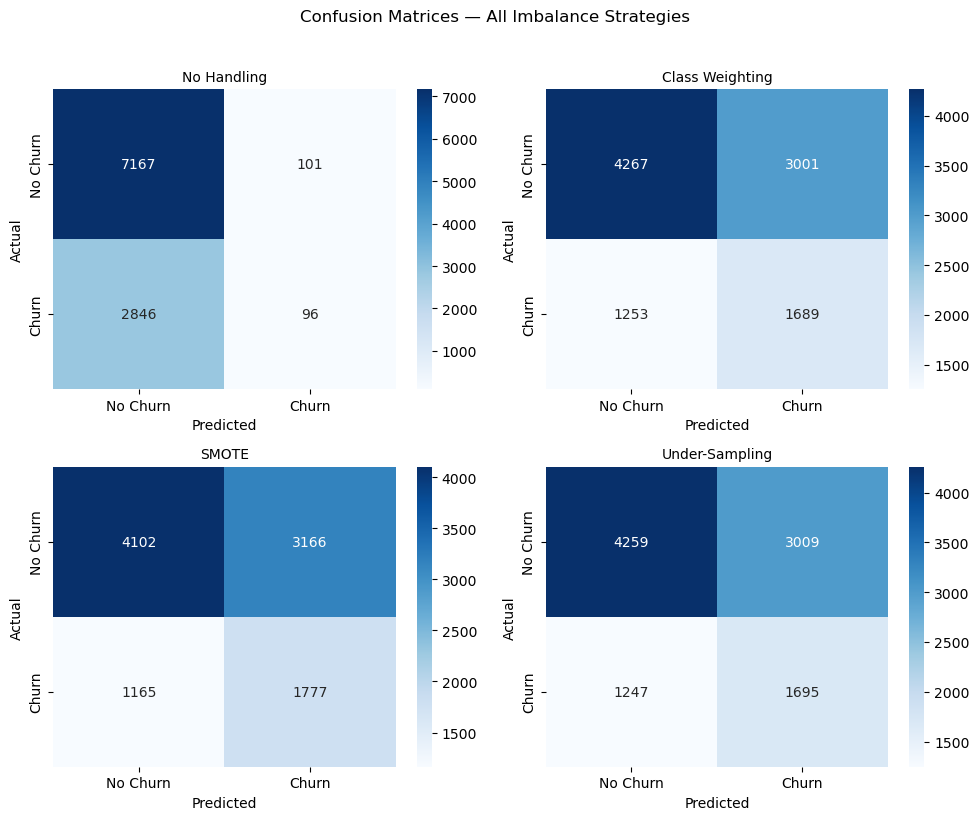

In [11]:


strategy_names = list(results.keys())
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, name in zip(axes, strategy_names):
    cm = results[name]["Confusion Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Imbalance Strategies", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Key Observations and Strategy Selection

The unhandled baseline confirms the problem clearly: a recall of 0.033 means that 97% of churners are missed entirely — the model has learned to predict non-churn by default. All three correction strategies raise recall to approximately 0.57–0.60 and F1 to approximately 0.44–0.45, demonstrating that imbalance handling is essential.

**Random under-sampling is selected** as the strategy for all subsequent notebooks on the following grounds:

1. **Performance parity:** F1 (0.4434) and ROC-AUC (0.6117) are statistically indistinguishable from class weighting (F1: 0.4426, ROC-AUC: 0.6123) and within 0.007 F1 of SMOTE — a difference well within the range of random variation.
2. **No synthetic data:** Under-sampling operates on real customer records, avoiding the methodological limitation of SMOTE's interpolation across binary one-hot encoded features.
3. **Computational efficiency:** The 42% reduction in training set size directly reduces the cost of cross-validation in later notebooks, which is practically significant given the grid and random search procedures in Notebooks 05 and 06.
4. **Simplicity and reproducibility:** The approach requires only a random seed to reproduce exactly, with no interpolation parameters to validate.

**Limitation acknowledged:** Discarding majority-class records means some real customer information is not used during training. This risk is mitigated by the relatively large dataset size (51,047 records) and confirmed by the consistent cross-validated performance across notebooks.

## Validation on XGBoost

The strategy comparison above used Logistic Regression as a controlled baseline to isolate the effect of each technique. Since XGBoost emerged as the best-performing model in subsequent notebooks, the comparison is repeated here to confirm that random under-sampling remains the most appropriate technique when applied to the final model.

In [12]:
from xgboost import XGBClassifier

xgb_results = {}

# 1. No handling
print("=== XGBoost — No Imbalance Handling ===")
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_results["Original"] = evaluate_model(xgb, X_test, y_test)

# 2. Class weighting
print("\n=== XGBoost — Class Weighting ===")
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42)
xgb_weighted.fit(X_train, y_train)
xgb_results["Class Weighting"] = evaluate_model(xgb_weighted, X_test, y_test)

# 3. SMOTE (reuse existing resampled data)
print("\n=== XGBoost — SMOTE ===")
xgb_smote = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_smote, y_train_smote)
xgb_results["SMOTE"] = evaluate_model(xgb_smote, X_test, y_test)

# 4. Random under-sampling (reuse existing resampled data)
print("\n=== XGBoost — Random Under-Sampling ===")
xgb_under = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_under.fit(X_train_under, y_train_under)
xgb_results["Under-Sampling"] = evaluate_model(xgb_under, X_test, y_test)

# Summary
xgb_summary = pd.DataFrame({
    k: {m: round(v[m], 4) for m in ["Precision", "Recall", "F1-score", "ROC-AUC"]}
    for k, v in xgb_results.items()
}).T

print("\nXGBoost — Imbalance Strategy Comparison:")
print(xgb_summary.to_string())

=== XGBoost — No Imbalance Handling ===

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.74      0.93      0.82      7268
       Churn       0.52      0.19      0.28      2942

    accuracy                           0.72     10210
   macro avg       0.63      0.56      0.55     10210
weighted avg       0.67      0.72      0.67     10210


=== XGBoost — Class Weighting ===

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.79      0.67      0.72      7268
       Churn       0.40      0.55      0.47      2942

    accuracy                           0.64     10210
   macro avg       0.60      0.61      0.60     10210
weighted avg       0.68      0.64      0.65     10210


=== XGBoost — SMOTE ===

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.74      0.91      0.82      7268
       Churn       0.50      0.21      0.30      2942

    accura